# Customer Churn Analysis

## Business Problem

Customer churn is a major challenge for subscription-based businesses. Retaining existing customers is often more cost-effective than acquiring new ones.

This project analyzes customer behavior to identify the factors influencing churn. The objective is to uncover actionable insights through exploratory data analysis (EDA) and build a machine learning model capable of predicting whether a customer is likely to churn.

## Objectives

- Understand customer demographics and subscription behavior.
- Identify factors contributing to customer churn.
- Visualize important patterns and trends.
- Build and evaluate churn prediction models.
- Provide business recommendations for improving customer retention.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7043
Columns : 21


In [4]:
df.info()
df.describe().T
df.describe(include="object").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


In [8]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Initial Observations

- The dataset contains 7,043 customer records.
- There are 21 variables including the target variable (Churn).
- Most columns are categorical.
- TotalCharges appears to be stored as an object and requires conversion.
- CustomerID is a unique identifier and will not contribute to prediction.
- Missing values will be investigated further before preprocessing.

In [9]:
df.drop("customerID", axis=1, inplace=True)

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [14]:
df.to_csv("../data/clean_customer_churn.csv", index=False)

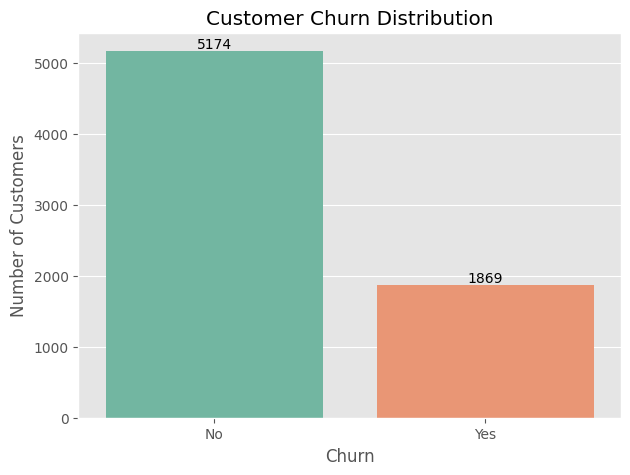

In [15]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="Churn", palette="Set2")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Insight

- Most customers remain with the company.
- However, a significant number have churned, making churn prediction a meaningful business problem.

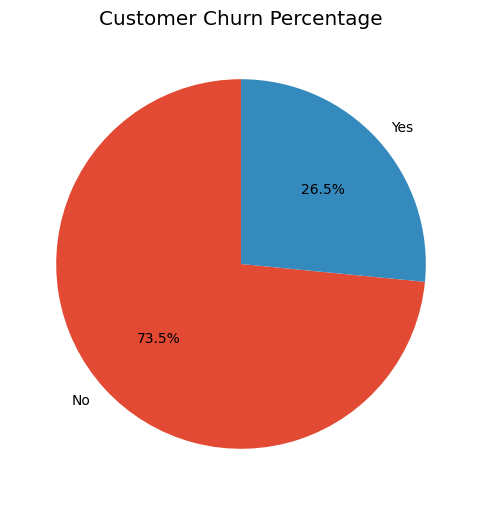

In [16]:
churn_percent = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    churn_percent,
    labels=churn_percent.index,
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Customer Churn Percentage")
plt.show()

Approximately one-fourth of customers have churned, indicating that improving retention could have a meaningful impact on revenue.

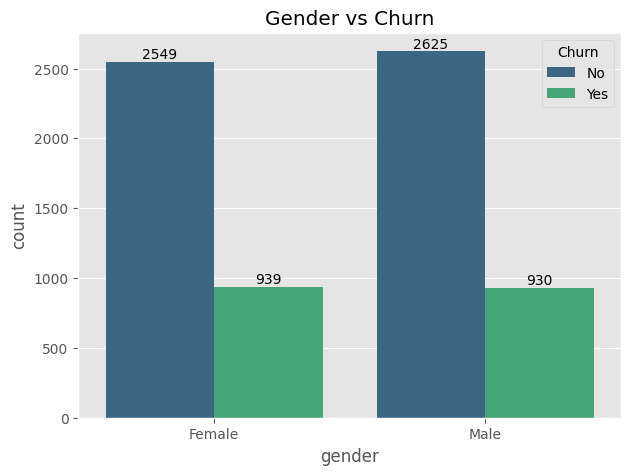

In [17]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender vs Churn")
plt.show()

Male and female customers exhibit similar churn patterns, suggesting that gender alone is not a strong predictor of churn.

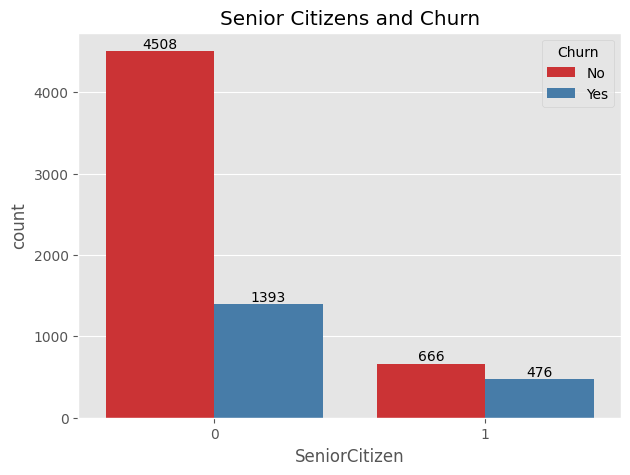

In [18]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="Set1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizens and Churn")
plt.show()

Senior citizens appear to have a higher proportion of churn compared to non-senior customers.

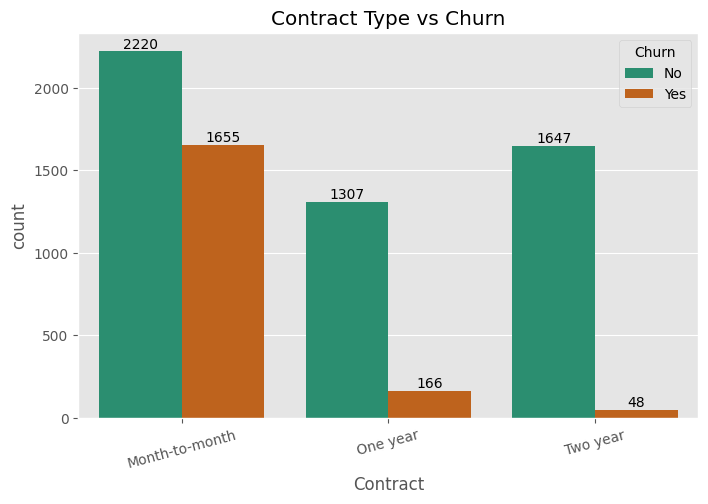

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Dark2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

Customers with month-to-month contracts exhibit the highest churn rates, while those with one-year and two-year contracts are considerably more likely to remain with the company.

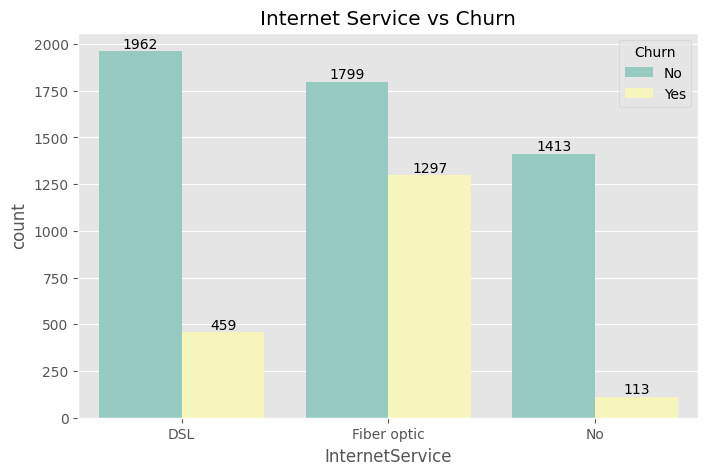

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Internet Service vs Churn")
plt.show()

Customers using fiber optic internet tend to churn more frequently than those using DSL or no internet service.

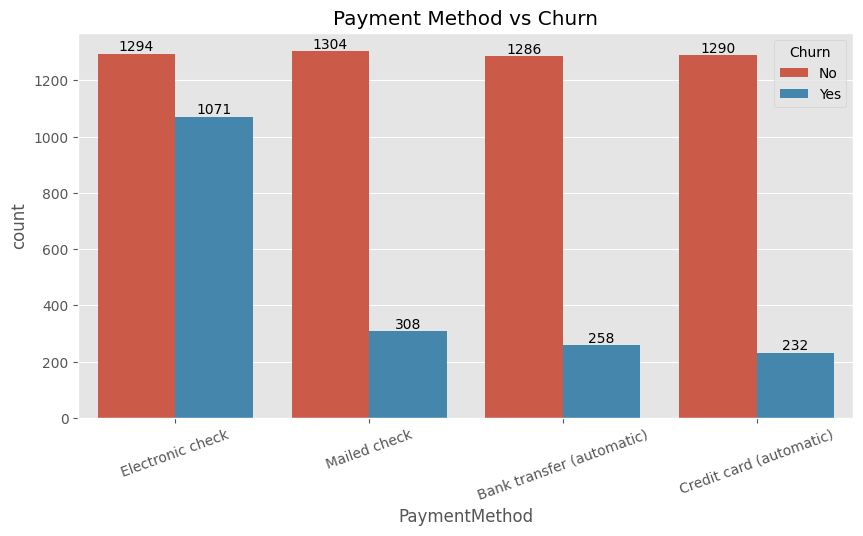

In [21]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

Electronic check users exhibit the highest churn rate, indicating potential dissatisfaction or differences in customer behavior.

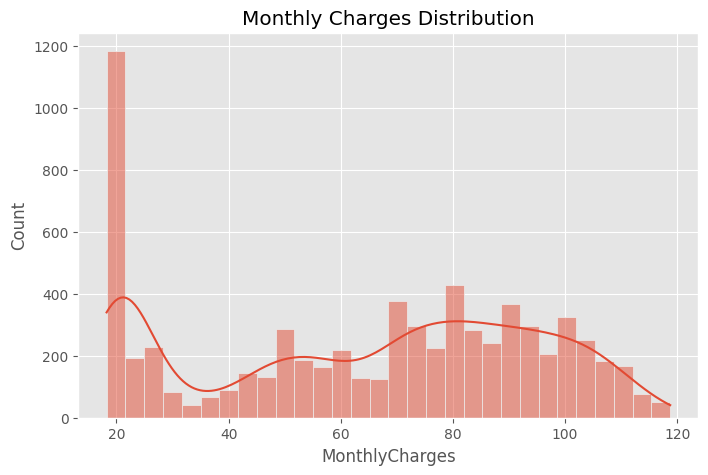

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

Monthly charges vary widely across customers, with a concentration in the lower pricing range.

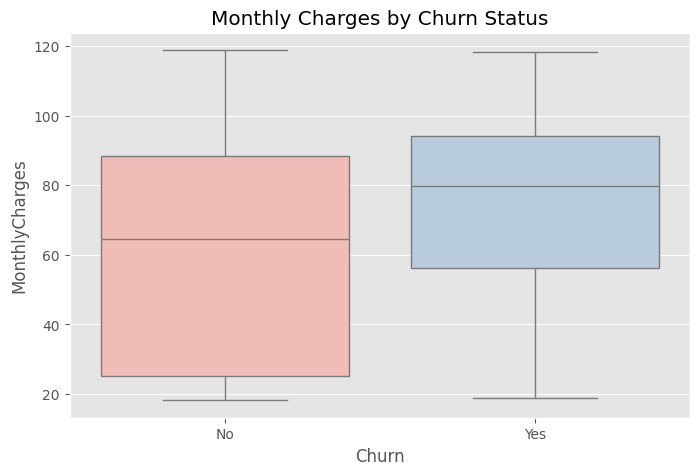

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Pastel1"
)

plt.title("Monthly Charges by Churn Status")
plt.show()

Customers who churn generally have higher monthly charges than those who remain.

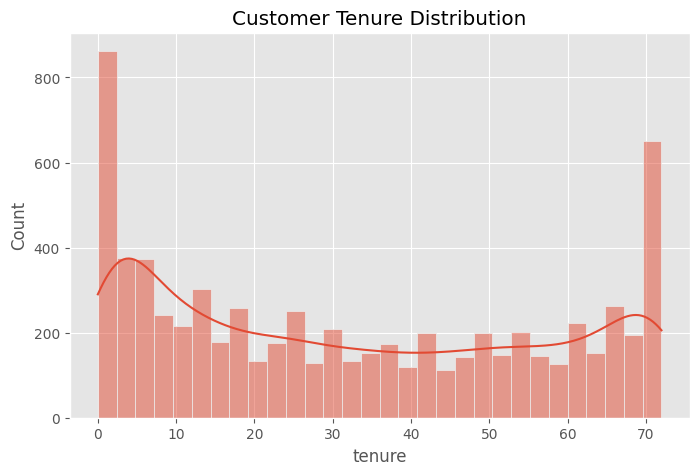

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.show()

Many customers are relatively new, while another large group has remained with the company for several years.

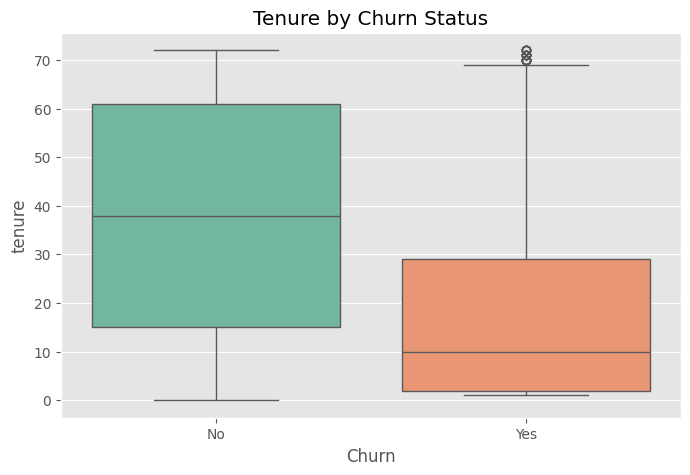

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Tenure by Churn Status")
plt.show()

Customers who churn typically have shorter tenures, indicating that new customers are at greater risk of leaving.

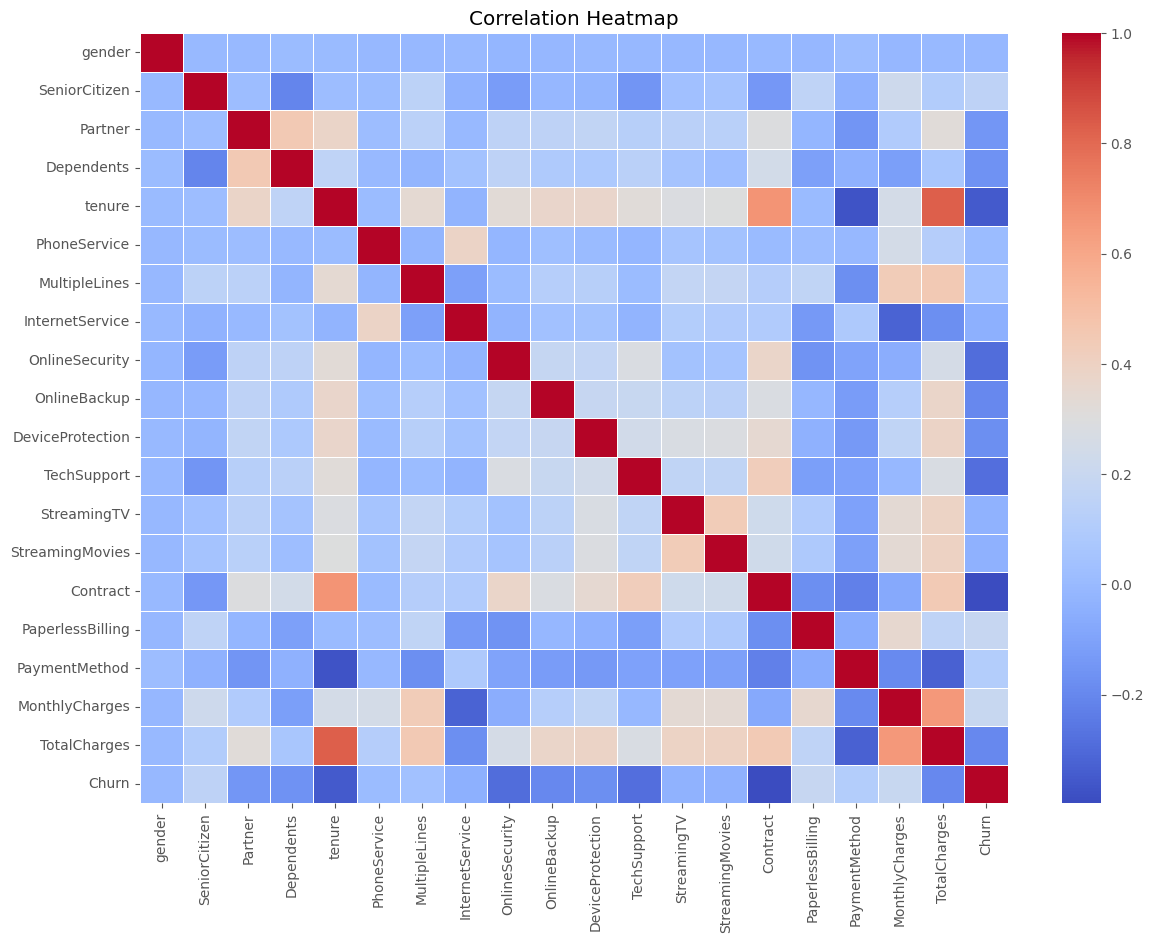

In [26]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object"):
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

The heatmap reveals relationships among variables and highlights which features are more strongly associated with customer churn, supporting subsequent feature selection and model development.

In [27]:
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (7043, 19)
Target Shape  : (7043,)


In [28]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['No' 'Yes']


In [29]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_cols)

print("\nNumerical Features")
print(numerical_cols)

Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [31]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [34]:
pd.Series(y_train).value_counts(normalize=True)

0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred_log = log_model.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_log))

Accuracy : 0.8055358410220014

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [38]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
y_pred_tree = tree_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_tree))

Accuracy : 0.7288857345635202


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

Accuracy : 0.7750177430801988


In [42]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.805536
2,Random Forest,0.775018
1,Decision Tree,0.728886


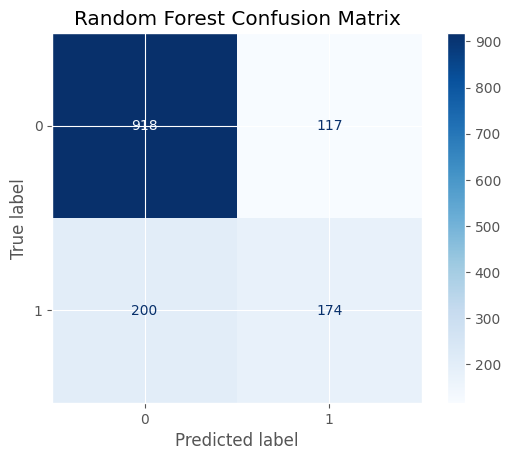

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [44]:
rf = rf_model.named_steps["classifier"]

feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

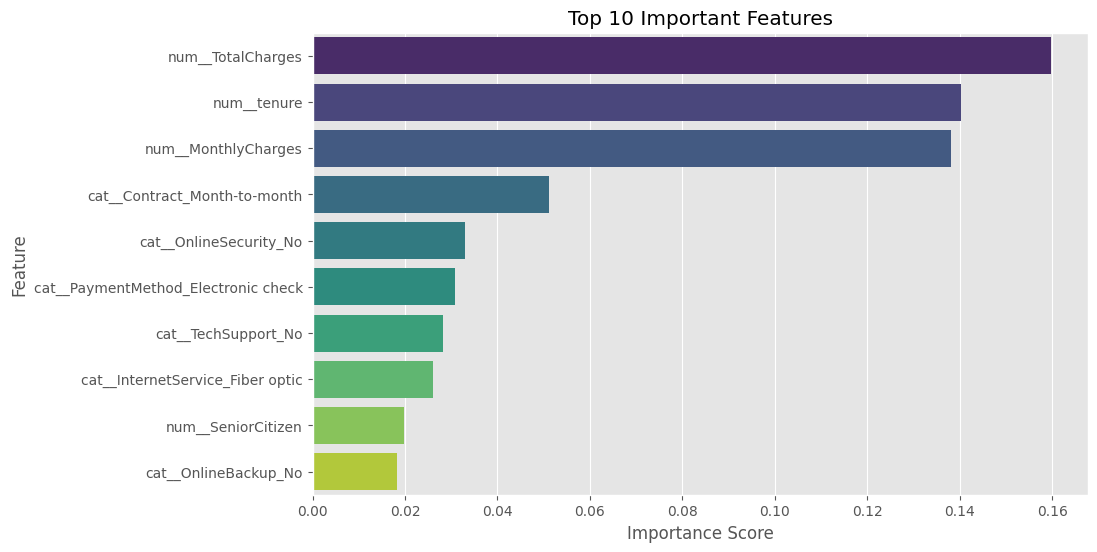

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [47]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(rf_model, "../models/churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Business Recommendations

Based on the analysis and predictive model, the following actions are recommended:

1. Encourage customers to switch from month-to-month to long-term contracts through discounts or loyalty incentives.

2. Identify customers with high monthly charges and provide personalized offers to improve retention.

3. Improve technical support services, as customers without tech support showed higher churn.

4. Launch targeted engagement campaigns for new customers, who are more likely to leave during their initial months.

5. Monitor customers identified as high-risk by the prediction model and proactively contact them before cancellation.